In [72]:
!python -m pip install pandas


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [73]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

In [115]:
import pandas as pd 
df1=pd.read_csv('customers.csv')
df2=pd.read_csv('transactions.csv')
# df=pd.merge(df1,df2,on='customer_id')
# df.to_csv('customer_orders.csv',index=False)

In [138]:
df1.head(15)

,customer_id,country,first_purchase,last_purchase,n_orders,total_spent,avg_basket,recency_days,tenure_days
0,46995,United Kingdom,2011-08-09 12:20:00,2011-11-16 12:20:00,2.28,57.34,26.440,23.83,99.17
1,22869,United Kingdom,2010-01-11 12:20:00,2011-10-30 12:20:00,46.53,19463.52,356.650,40.92,657.12
2,12593,France,2011-05-05 09:29:00,2011-05-05 09:29:00,1.00,39.50,39.500,218.00,218.00
3,25889,United Kingdom,2008-07-14 12:20:00,2010-02-22 12:20:00,0.98,24.53,25.150,655.23,588.26
4,52931,United Kingdom,2009-08-29 12:20:00,2010-11-04 12:20:00,2.00,47.80,23.180,400.35,432.64
5,56166,United Kingdom,2011-09-10 12:20:00,2011-10-25 12:20:00,1.06,54.91,56.320,45.32,45.83
6,24264,United Kingdom,2008-06-15 12:20:00,2009-12-17 12:20:00,0.86,13.26,13.080,722.55,550.00
7,62940,United Kingdom,2011-03-23 12:20:00,2011-11-30 12:20:00,3.05,20.78,9.030,9.09,252.42
8,17435,United Kingdom,2010-10-24 13:55:00,2010-10-24 13:55:00,1.00,16.35,16.350,410.00,410.00
9,50400,United Kingdom,2011-06-04 12:20:00,2011-11-04 12:20:00,1.79,33.60,13.230,35.50,153.21


In [137]:
df2.head(15)

,invoice_id,customer_id,product_code,product_name,quantity,unit_price,invoice_date,country
0,513574,NaN,22382,LUNCH BAG SPACEBOY DESIGN,2.0,4.21,2010-06-25 15:13:00,United Kingdom
1,609421,NaN,21028,PURPLE GEMSTONE BRACELET,2.0,8.95,2011-10-16 12:20:00,United Kingdom
2,515609,NaN,47591B,SCOTTIES CHILDRENS APRON,1.0,1.66,2010-07-13 15:44:00,United Kingdom
3,501320,15123.0,22334,DINOSAUR PARTY BAG + STICKER SET,8.0,1.65,2010-03-16 09:49:00,United Kingdom
4,521822,12714.0,21933,PINK VINTAGE PAISLEY PICNIC BAG,5.0,2.95,2010-09-09 10:37:00,France
5,630916,20607.0,84660A,WHITE STITCHED WALL CLOCK,NaN,0.79,2010-06-08 12:20:00,United Kingdom
6,503061,NaN,22381,TOY TIDY PINK RETROSPOT,84.0,4.95,2010-03-29 16:47:00,United Kingdom
7,702453,33347.0,22135,CURIOUS IMAGES GIFT WRAP SET,60.0,0.65,2011-01-02 12:20:00,United Kingdom
8,554808,17059.0,21166,COOK WITH WINE METAL SIGN,1.0,2.08,2011-05-26 13:01:00,United Kingdom
9,756479,NaN,35972,PINK METAL CHICKEN HEART,24.0,1.49,2010-11-29 12:20:00,Czech Republic


In [ ]:
df1['customer_id'].nunique()

50000

Combien de clients ?
50000

In [ ]:
df2['invoice_id'].count()

np.int64(1837137)

Combien de transactions ? 253545

In [ ]:
df2["invoice_date"] = pd.to_datetime(df2["invoice_date"], errors="coerce")

In [ ]:
start_date = df2["invoice_date"].min()
end_date = df2["invoice_date"].max()

print("Période couverte :", start_date, "au", end_date)

Période couverte : 2007-07-06 12:20:00 au 2011-12-09 12:50:00


Sur quelle période ? Les transactions ont été de réalisé sur la période du 2007-07-06 12:20:00 au 2011-12-09 12:50:00

In [ ]:
df1.describe()

,customer_id,n_orders,total_spent,avg_basket,recency_days,tenure_days
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,38390.294040,4.746364,421.538510,65.428104,238.454858,482.477138
std,14517.833799,9.551931,2014.135812,139.874935,218.933454,224.947664
min,12346.000000,0.850000,0.160000,0.160000,0.000000,0.000000
25%,25941.750000,1.060000,36.987500,21.787500,38.137500,343.822500
50%,38441.500000,2.220000,99.640000,38.810000,168.000000,532.980000
75%,50941.250000,5.210000,280.225000,69.100000,411.512500,662.260000
max,63441.000000,292.780000,69630.660000,5876.150000,844.590000,848.620000


In [ ]:
df2.describe(include="all")

,invoice_id,customer_id,product_code,product_name,quantity,unit_price,invoice_date,country
count,1837137,1.418879e+06,1837137,1829595,1.820950e+06,1.837137e+06,1837137,1837137
unique,253545,NaN,5305,5698,NaN,NaN,NaN,43
top,537434,NaN,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,United Kingdom
freq,1350,NaN,11299,51779,NaN,NaN,NaN,1681829
mean,NaN,2.241318e+04,NaN,NaN,1.122359e+01,3.902841e+00,2010-11-29 06:40:04.388001,NaN
min,NaN,1.234600e+04,NaN,NaN,-8.099500e+04,-5.359436e+04,2007-07-06 12:20:00,NaN
25%,NaN,1.489500e+04,NaN,NaN,1.000000e+00,1.250000e+00,2010-06-05 12:20:00,NaN
50%,NaN,1.749100e+04,NaN,NaN,4.000000e+00,2.100000e+00,2010-12-01 12:40:00,NaN
75%,NaN,2.179900e+04,NaN,NaN,1.200000e+01,3.750000e+00,2011-06-23 09:38:00,NaN
max,NaN,6.344100e+04,NaN,NaN,8.099500e+04,3.897000e+04,2011-12-09 12:50:00,NaN


In [ ]:
df1.isna().sum()

customer_id       0
country           0
first_purchase    0
last_purchase     0
n_orders          0
total_spent       0
avg_basket        0
recency_days      0
tenure_days       0
dtype: int64

In [ ]:
df2.isna().sum()

invoice_id           0
customer_id     418258
product_code         0
product_name      7542
quantity         16187
unit_price           0
invoice_date         0
country              0
dtype: int64

Dans le dataset des transactions on remarque que (418258) clients n'ont pas de customer_id , 7542 de product_name sont manquant et 16187 donnée manquant dans la colonne quantity

In [ ]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     50000 non-null  int64  
 1   country         50000 non-null  str    
 2   first_purchase  50000 non-null  str    
 3   last_purchase   50000 non-null  str    
 4   n_orders        50000 non-null  float64
 5   total_spent     50000 non-null  float64
 6   avg_basket      50000 non-null  float64
 7   recency_days    50000 non-null  float64
 8   tenure_days     50000 non-null  float64
dtypes: float64(5), int64(1), str(3)
memory usage: 3.4 MB


In [ ]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 1837137 entries, 0 to 1837136
Data columns (total 8 columns):
 #   Column        Dtype  
---  ------        -----  
 0   invoice_id    str    
 1   customer_id   float64
 2   product_code  str    
 3   product_name  str    
 4   quantity      float64
 5   unit_price    float64
 6   invoice_date  str    
 7   country       str    
dtypes: float64(3), str(5)
memory usage: 112.1 MB


In [ ]:
df1.duplicated().sum()

np.int64(0)

In [ ]:
df2[['invoice_id','customer_id','product_code']].duplicated().sum()

np.int64(46602)

In [ ]:
df2['customer_id'].isnull().sum()

np.int64(418258)

Etapes 2:

1) Les customer_id manquants: que représentent ces lignes ? Faut-il les supprimer ou les conserver ?

Les customer_id manquants dans transactions.csv peuvent indiquer des transactions sans client associé(probablement guest checkout ou transactions techniques), ce qui peut poser des problèmes pour l'analyse. Nous pouvons les conserver pour l'analyse client mais les éliminer pour l'analyse des comportments client pour éviter les biais.

2) Les quantity négatives: d'où viennent-elles ? Quel impact sur les agrégations futures ?

In [ ]:
df2["is_credit_invoice"] = df2["invoice_id"].astype(str).str.startswith("C")

In [ ]:
df2["is_negative_qty"] = df2["quantity"] < 0

In [ ]:
# # Total lignes
# total = len(df2)

# # Comptages
# cross = pd.crosstab(df2["is_credit_invoice"], df2["is_negative_qty"])

# # Pourcentage par rapport au total
# cross_percent = cross / total * 100

# cross_percent

is_negative_qty,False,True
is_credit_invoice,,
False,98.730906,0.207987
True,0.000054,1.061053


In [ ]:
pd.crosstab(
    df2["is_credit_invoice"],
    df2["is_negative_qty"],
    normalize="index"
) * 100

is_negative_qty,False,True
is_credit_invoice,,
False,99.789783,0.210217
True,0.005130,99.994870


On constate que plus de 99% des facture qui commence par un C sont relié a une quantité négative et seulement une 0,3% des factures normale corresponde a des quantité négative . Donc on en déduit que les quantité négative sont dues a des retour clients

In [ ]:
df2[df2["unit_price"] == 0].shape[0]

10674

In [ ]:
df2[df2["unit_price"] == 0].shape[0] / len(df2) * 100

0.5810127388431021

In [ ]:
df2[df2["unit_price"] == 0].head()

,invoice_id,customer_id,product_code,product_name,quantity,unit_price,invoice_date,country,is_credit_invoice,is_negative_qty
26,768176,NaN,22990,WHITE CHERRY LIGHTS,24.0,0.0,2009-06-08 12:20:00,United Kingdom,False,False
113,548380,NaN,22127,Dotcom sold in 6's,-60.0,0.0,2011-03-30 16:44:00,United Kingdom,False,True
136,734573,44742.0,21145,CHARLIE + LOLA RED HOT WATER BOTTLE,1.0,0.0,2010-12-29 12:20:00,United Kingdom,False,False
252,519368,NaN,37449,NaN,7.0,0.0,2010-08-16 13:09:00,United Kingdom,False,False
261,508700,NaN,22192,NaN,-1.0,0.0,2010-05-17 17:05:00,United Kingdom,False,True


Les lignes avec unit_price = 0 représentent 0.58 % des transactions. Leur faible proportion et la présence fréquente de valeurs manquantes suggèrent des ajustements techniques ou anomalies d’export plutôt qu’un cas métier standard. Elles seront exclues des analyses de panier et de chiffre d’affaires.

Les product_code atypiques:

In [70]:
df_non_product = df2[~df2["product_code"].astype(str).str.match(r"^\d+$")]
df_non_product["product_code"].value_counts()

product_code
85123A    11299
85099B     7777
82494L     4066
85099F     3591
85099C     3525
          ...  
37490C        1
84867a        1
35004s        1
71028A        1
79082C        1
Name: count, Length: 1715, dtype: int64

In [ ]:
df2["product_code"].unique()[:50]

<StringArray>
[ '22382',  '21028', '47591B',  '22334',  '21933', '84660A',  '22381',
  '22135',  '21166',  '35972', '35004S',  '21845',  '22586',  '22962',
  '90132',  '20717',  '22605',  '22228',  '23283', '84912A',  '72741',
  '23613',  '20980', '47591C',  '21204',  '84689',  '22990',  '23424',
  '23535',  '21441',  '22573',  '22350', '47556B',  '85178',  '85092',
  '21336',  '84454',  '21020',  '37500',  '22386',  '82597', '47574A',
  '21476',  '48187',  '70006',  '21928',  '22717',  '21781',  '23322',
  '21164']
Length: 50, dtype: str

In [76]:
df2[df2["product_code"].str.contains("POST|CARRIAGE|BANK|ADJUST|TEST", case=False, na=False)]

,invoice_id,customer_id,product_code,product_name,quantity,unit_price,invoice_date,country
393,C510764,NaN,BANK CHARGES,Bank Charges,-1.0,589.59,2010-06-03 13:12:00,United Kingdom
407,541962,12693.0,POST,POSTAGE,2.0,18.00,2011-01-24 12:58:00,Germany
709,743436,49834.0,TEST002,CHOCOLATE BOX RIBBONS,3.0,1.25,2010-03-02 12:20:00,United Kingdom
1767,553566,12690.0,POST,POSTAGE,3.0,18.00,2011-05-18 09:09:00,France
3069,540900,12712.0,POST,POSTAGE,2.0,18.00,2011-01-12 11:46:00,Germany
...,...,...,...,...,...,...,...,...
1834577,555869,NaN,POST,POSTAGE,1.0,5.15,2011-06-07 14:54:00,United Kingdom
1835379,635957,20826.0,BANK CHARGES,"WHITE TEA,COFFEE,SUGAR JARS",12.0,1.95,2011-10-19 12:20:00,United Kingdom
1835715,489444,12636.0,POST,POSTAGE,1.0,141.00,2009-12-01 09:55:00,USA
1835905,565785,12461.0,POST,POSTAGE,5.0,40.00,2011-09-06 16:57:00,Switzerland


In [34]:
#Calculez line_total = quantity × unit_price. Vérifiez la cohérence.
line_total = df2['quantity'] * df2['unit_price']
print(line_total)

0           8.42
1          17.90
2           1.66
3          13.20
4          14.75
           ...  
1837132    13.92
1837133     6.60
1837134     8.50
1837135    24.96
1837136    11.80
Length: 1837137, dtype: float64


In [78]:
line_total.describe()

count    1.820950e+06
mean     2.024693e+01
std      2.303198e+02
min     -1.684696e+05
25%      3.750000e+00
50%      1.008000e+01
75%      1.770000e+01
max      1.684696e+05
dtype: float64

Dans customers.csv

In [35]:
# Cohérence des dates ( first_purchase ≤ last_purchase )
df1[df1['first_purchase'] > df1['last_purchase']]

,customer_id,country,first_purchase,last_purchase,n_orders,total_spent,avg_basket,recency_days,tenure_days


In [37]:
#Valeurs aberrantes dans total_spent , n_orders , avg_basket
df1[df1['total_spent'] < 0]
df1[df1['n_orders'] < 0]
df1[df1['avg_basket'] < 0]

,customer_id,country,first_purchase,last_purchase,n_orders,total_spent,avg_basket,recency_days,tenure_days


In [38]:
#Clients avec une seule transaction vs clients récurrents: quelle proportion ?
single_transaction = df2.groupby("customer_id").size()
recurring_customers = single_transaction[single_transaction > 1].count()
single_customers = single_transaction[single_transaction == 1].count()
total_customers = len(single_transaction)
proportion_recurring = recurring_customers / total_customers * 100
proportion_single = single_customers / total_customers * 100
print(f"Proportion de clients récurrents: {proportion_recurring:.2f}%")
print(f"Proportion de clients avec une seule transaction: {proportion_single:.2f}%")

Proportion de clients récurrents: 83.52%
Proportion de clients avec une seule transaction: 16.48%


Nettoyage

In [80]:
len(df_non_product) / len(df2) * 100

13.053735241302093

Nettoyage pour analyse global

In [97]:
df_clean = df2.copy()

# Dates + line_total
df_clean["invoice_date"] = pd.to_datetime(df_clean["invoice_date"], errors="coerce")
df_clean = df_clean.dropna(subset=["invoice_id", "invoice_date"])

# Retirer lignes inexploitables pour CA
df_clean = df_clean.dropna(subset=["quantity", "unit_price"])
df_clean = df_clean[(df_clean["quantity"] > 0) & (df_clean["unit_price"] > 0)]

# Retirer codes non-produits (à adapter selon ce que tu observes)
mask_nonprod = df_clean["product_code"].astype(str).str.contains(
    "POST|CARRIAGE|BANK|ADJUST|TEST|SHIPPING", case=False, na=False
)
df_clean = df_clean[~mask_nonprod].copy()

df_clean["line_total"] = df_clean["quantity"] * df_clean["unit_price"]

print(df_clean.shape)

(1787439, 9)


Nettoyage client-level (pour fréquence / RFM / géographie client)

In [105]:
df_cust = df_clean.dropna(subset=["customer_id"]).copy()
print(df_cust.shape)

(1381264, 9)


In [86]:
df2["line_total"] = df2["quantity"] * df2["unit_price"]
df2["line_total"].describe()

count    1.820950e+06
mean     2.024693e+01
std      2.303198e+02
min     -1.684696e+05
25%      3.750000e+00
50%      1.008000e+01
75%      1.770000e+01
max      1.684696e+05
Name: line_total, dtype: float64

In [98]:
df_clean.head()

,invoice_id,customer_id,product_code,product_name,quantity,unit_price,invoice_date,country,line_total
0,513574,NaN,22382,LUNCH BAG SPACEBOY DESIGN,2.0,4.21,2010-06-25 15:13:00,United Kingdom,8.42
1,609421,NaN,21028,PURPLE GEMSTONE BRACELET,2.0,8.95,2011-10-16 12:20:00,United Kingdom,17.90
2,515609,NaN,47591B,SCOTTIES CHILDRENS APRON,1.0,1.66,2010-07-13 15:44:00,United Kingdom,1.66
3,501320,15123.0,22334,DINOSAUR PARTY BAG + STICKER SET,8.0,1.65,2010-03-16 09:49:00,United Kingdom,13.20
4,521822,12714.0,21933,PINK VINTAGE PAISLEY PICNIC BAG,5.0,2.95,2010-09-09 10:37:00,France,14.75


In [99]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 1787439 entries, 0 to 1837136
Data columns (total 9 columns):
 #   Column        Dtype         
---  ------        -----         
 0   invoice_id    str           
 1   customer_id   float64       
 2   product_code  str           
 3   product_name  str           
 4   quantity      float64       
 5   unit_price    float64       
 6   invoice_date  datetime64[us]
 7   country       str           
 8   line_total    float64       
dtypes: datetime64[us](1), float64(4), str(4)
memory usage: 136.4 MB


Distribution des achats :
1)Distribution du montant des paniers (attention aux outliers: clients B2B ?)

2)Distribution de la fréquence d'achat par client

3)Quelle proportion de clients génère 80% du chiffre d'affaires ? (loi de Pareto)


In [95]:
df = df_clean.copy()

# Sécurité
df["invoice_date"] = pd.to_datetime(df["invoice_date"])
df["line_total"] = df["quantity"] * df["unit_price"]

count    237971.000000
mean        161.372040
std         679.245012
min           0.190000
50%          51.000000
75%         136.200000
90%         345.250000
95%         571.350000
99%        1613.181000
max      168469.600000
Name: line_total, dtype: float64


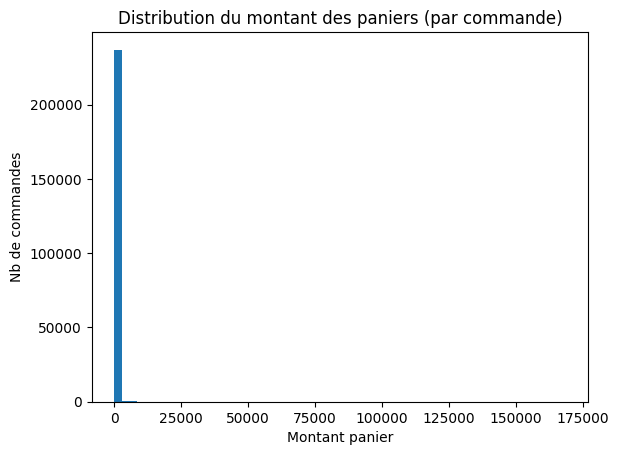

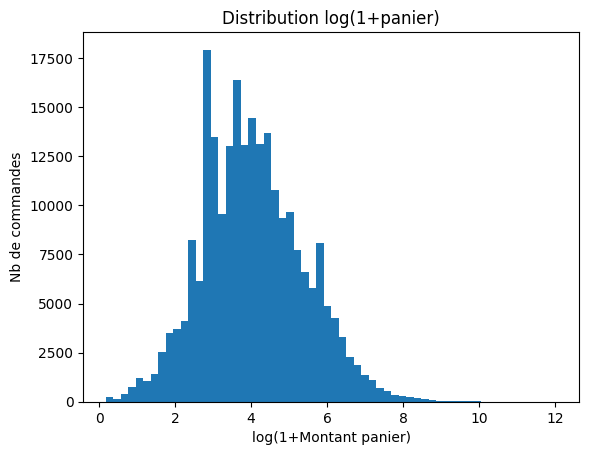

In [ ]:
# 1)Distribution du montant des paniers (attention aux outliers: clients B2B ?)
basket = df_clean.groupby("invoice_id")["line_total"].sum()

print(basket.describe(percentiles=[.5,.75,.9,.95,.99]))

plt.figure()
plt.hist(basket, bins=60)
plt.title("Distribution du montant des paniers (par commande)")
plt.xlabel("Montant panier")
plt.ylabel("Nb de commandes")
plt.show()

plt.figure()
plt.hist(np.log1p(basket), bins=60)
plt.title("Distribution log(1+panier)")
plt.xlabel("log(1+Montant panier)")
plt.ylabel("Nb de commandes")
plt.show()

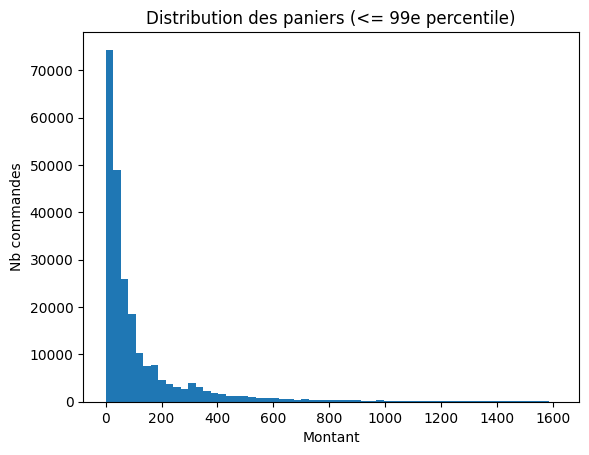

In [116]:
p99 = basket.quantile(0.99)

plt.figure()
plt.hist(basket[basket <= p99], bins=60)
plt.title("Distribution des paniers (<= 99e percentile)")
plt.xlabel("Montant")
plt.ylabel("Nb commandes")
plt.show()

Sur le graphe on constate une distribution des paniers fortement asymétrique, avec une longue traîne à droite.C'est due au fait que 99% des commandes sont inférieures à 1 613€, mais quelques commandes exceptionnelles dépassent 100 000€, suggérant la présence de clients B2B ou de commandes atypiques. Pour analyser la structure centrale du marché,nous avons faire une visualisation logarithmique ou tronquée au 99e.

In [106]:
orders_per_customer = df_cust.groupby("customer_id")["invoice_id"].nunique()

proportion_single = (orders_per_customer == 1).mean() * 100
proportion_recurring = (orders_per_customer > 1).mean() * 100

print(f"Clients 1 commande: {proportion_single:.2f}%")
print(f"Clients récurrents: {proportion_recurring:.2f}%")

Clients 1 commande: 41.77%
Clients récurrents: 58.23%


In [102]:
basket.skew()

np.float64(87.11537911889319)

In [107]:
rev_per_customer = df_cust.groupby("customer_id")["line_total"].sum().sort_values(ascending=False)
cum = rev_per_customer.cumsum() / rev_per_customer.sum()

share_customers_for_80 = (cum <= 0.8).mean() * 100
print(f"% de clients qui font 80% du CA: {share_customers_for_80:.2f}%")

% de clients qui font 80% du CA: 13.17%


Saisonnalité

Y a-t-il des pics saisonniers visibles ? Lesquels ? Qu'impliquent-ils pour les campagnes marketing ?
Comparez les patterns sur les deux années disponibles: la saisonnalité est-elle stable ?

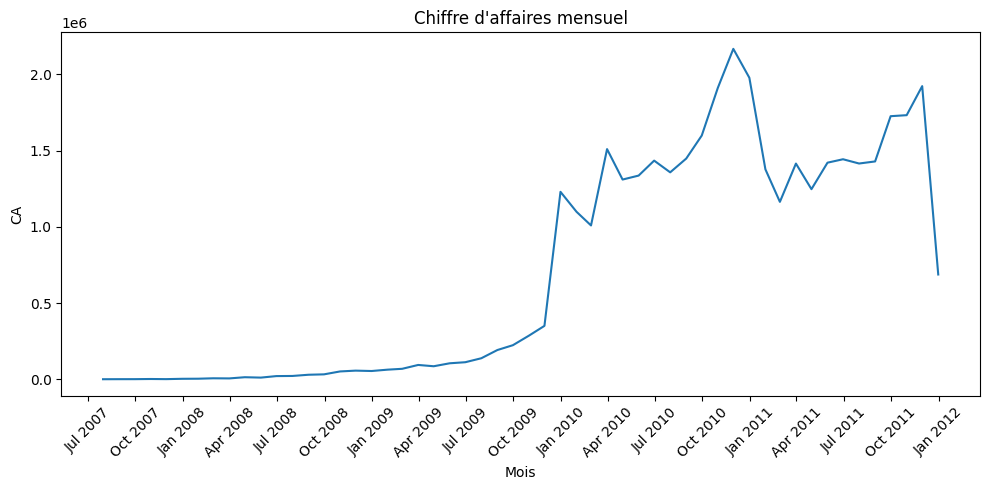

In [142]:
# #Evolution du chiffre d'affaires mensuel sur la période disponible
# monthly_rev = df_clean.set_index("invoice_date").resample("ME")["line_total"].sum()

# plt.figure()
# plt.plot(monthly_rev.index, monthly_rev.values)
# plt.title("Chiffre d'affaires mensuel")
# plt.xlabel("Mois")
# plt.ylabel("CA")
# plt.show()
# import matplotlib.pyplot as plt
# import matplotlib.dates as mdates

# Evolution du chiffre d'affaires mensuel
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Sécurité : datetime
df_clean["invoice_date"] = pd.to_datetime(df_clean["invoice_date"])

monthly_rev = (
    df_clean
    .set_index("invoice_date")
    .resample("ME")["line_total"]
    .sum()
)

fig, ax = plt.subplots(figsize=(10,5))

ax.plot(monthly_rev.index, monthly_rev.values)

# 🔹 Un tick tous les 3 mois (plus lisible)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

# 🔹 Format mois + année
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)

ax.set_title("Chiffre d'affaires mensuel")
ax.set_xlabel("Mois")
ax.set_ylabel("CA")

plt.tight_layout()
plt.show()

Y a-t-il des pics saisonniers visibles ? Lesquels ? Qu'impliquent-ils pour les campagnes marketing ?

Comparez les patterns sur les deux années disponibles: la saisonnalité est-elle stable ?

Géographie :

country
United Kingdom    0.909476
Germany           0.019775
France            0.014678
Spain             0.006244
Belgium           0.005589
Portugal          0.004115
Switzerland       0.003685
Netherlands       0.003132
Italy             0.003030
Norway            0.002907
Name: proportion, dtype: float64


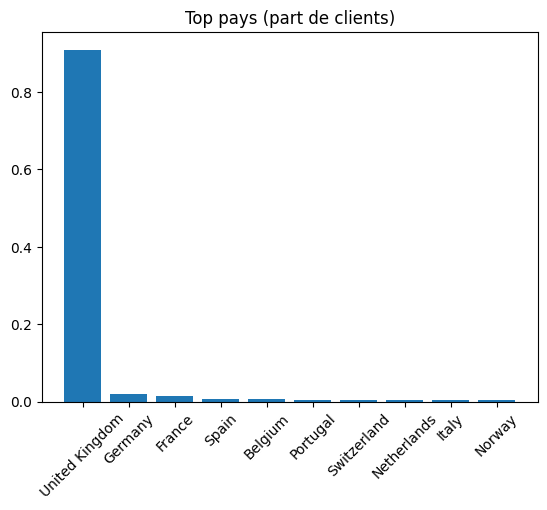

In [110]:
# Répartition des clients par pays
customer_country = df_cust.groupby("customer_id")["country"].agg(lambda x: x.mode().iloc[0])
country_share = customer_country.value_counts(normalize=True)

print(country_share.head(10))

plt.figure()
plt.bar(country_share.head(10).index, country_share.head(10).values)
plt.title("Top pays (part de clients)")
plt.xticks(rotation=45)
plt.show()

In [112]:
#Les comportements d'achat (panier moyen, fréquence) varient-ils selon la géographie ?
country_stats = df_cust.groupby("country").agg(
    avg_basket=("line_total", "mean"),
    frequency=("invoice_id", "nunique")
).sort_values("avg_basket", ascending=False)
print(country_stats.head(10))

                      avg_basket  frequency
country                                    
Netherlands            86.162707        770
Singapore              72.126648         16
Japan                  71.700845        112
Australia              67.160091        419
Denmark                61.062045        320
Thailand               58.516902         14
Sweden                 52.858270        281
United Arab Emirates   50.042474         57
Malta                  42.097408         40
Norway                 38.593207        244


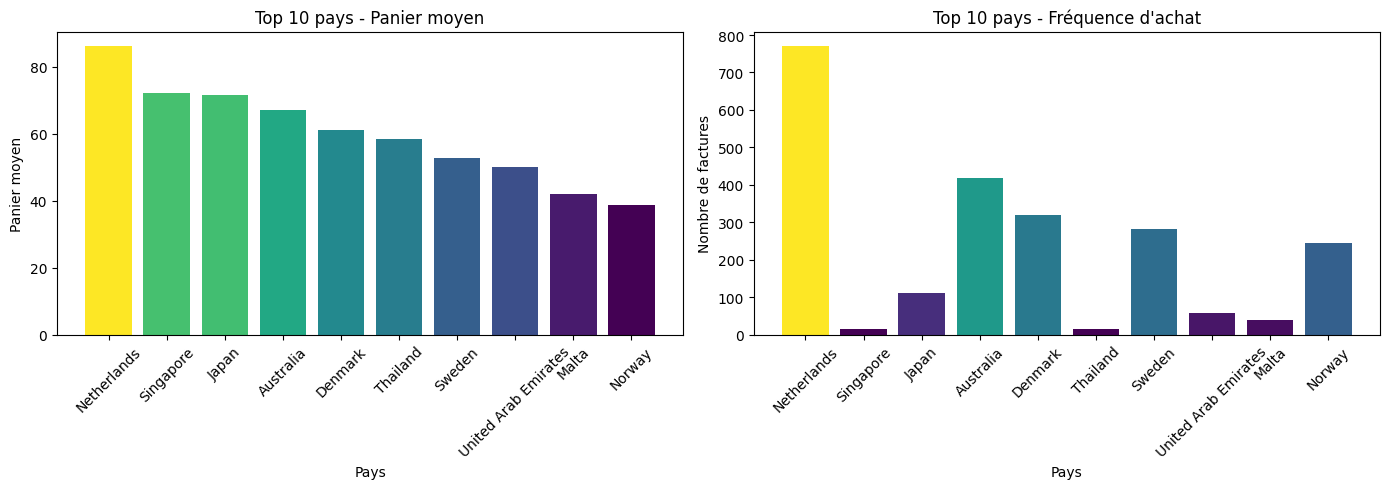

In [146]:
import matplotlib.pyplot as plt
import numpy as np

top10 = country_stats.head(10)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# --------- Graphique 1 : Panier moyen ---------
norm1 = plt.Normalize(top10["avg_basket"].min(),
                      top10["avg_basket"].max())
colors1 = plt.cm.viridis(norm1(top10["avg_basket"]))

axes[0].bar(top10.index, top10["avg_basket"], color=colors1)
axes[0].set_title("Top 10 pays - Panier moyen")
axes[0].set_xlabel("Pays")
axes[0].set_ylabel("Panier moyen")
axes[0].tick_params(axis='x', rotation=45)


# --------- Graphique 2 : Fréquence ---------
norm2 = plt.Normalize(top10["frequency"].min(),
                      top10["frequency"].max())
colors2 = plt.cm.viridis(norm2(top10["frequency"]))

axes[1].bar(top10.index, top10["frequency"], color=colors2)
axes[1].set_title("Top 10 pays - Fréquence d'achat")
axes[1].set_xlabel("Pays")
axes[1].set_ylabel("Nombre de factures")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [121]:
#Corrélation entre récence et montant dépensé ? (RFM)
snapshot_date = df_clean["invoice_date"].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby("customer_id").agg(
    last_purchase=("invoice_date", "max"),
    frequency=("invoice_id", "nunique"),
    monetary=("line_total", "sum"),
)

rfm["recency"] = (snapshot_date - rfm["last_purchase"]).dt.days
rfm = rfm.drop(columns=["last_purchase"])
print(rfm.head())

             frequency  monetary  recency
customer_id                              
12346.0              3  77352.96      326
12347.0              8   5633.32        2
12348.0              5   1658.40       75
12349.0              3   3678.69       19
12350.0              1    294.40      310


In [122]:
rfm[["recency","monetary"]].corr()

,recency,monetary
recency,1.000000,-0.092488
monetary,-0.092488,1.000000


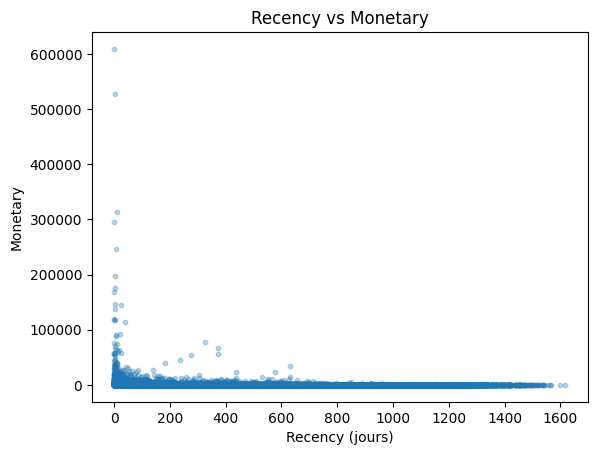

In [123]:
plt.figure()
plt.scatter(rfm["recency"], rfm["monetary"], alpha=0.3, s=10)
plt.xlabel("Recency (jours)")
plt.ylabel("Monetary")
plt.title("Recency vs Monetary")
plt.show()

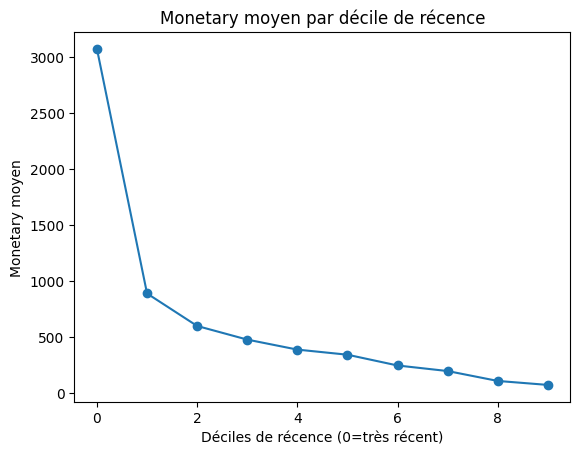

In [124]:
rfm["rec_bin"] = pd.qcut(rfm["recency"], 10, duplicates="drop")
mean_monetary = rfm.groupby("rec_bin")["monetary"].mean()

plt.figure()
plt.plot(range(len(mean_monetary)), mean_monetary.values, marker="o")
plt.title("Monetary moyen par décile de récence")
plt.xlabel("Déciles de récence (0=très récent)")
plt.ylabel("Monetary moyen")
plt.show()

In [127]:
#Relation entre fréquence et panier moyen: les clients fréquents dépensent-ils plus par visite ?
rfm["avg_basket"] = rfm["monetary"] / rfm["frequency"]
print(rfm[["frequency", "avg_basket"]].corr())

            frequency  avg_basket
frequency    1.000000    0.047801
avg_basket   0.047801    1.000000


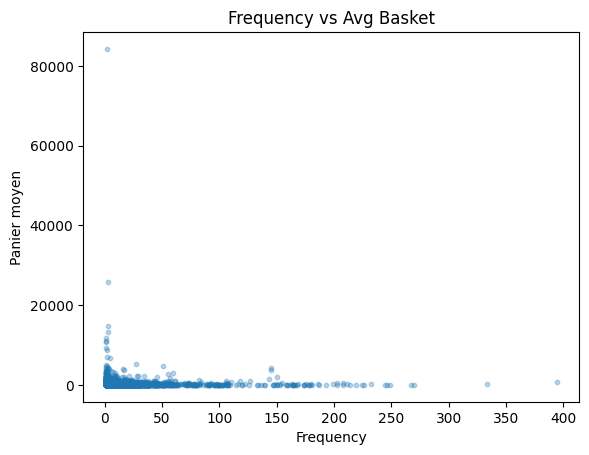

In [129]:
plt.figure()
plt.scatter(rfm["frequency"], rfm["avg_basket"], alpha=0.3, s=10)
plt.xlabel("Frequency")
plt.ylabel("Panier moyen")
plt.title("Frequency vs Avg Basket")
plt.show()

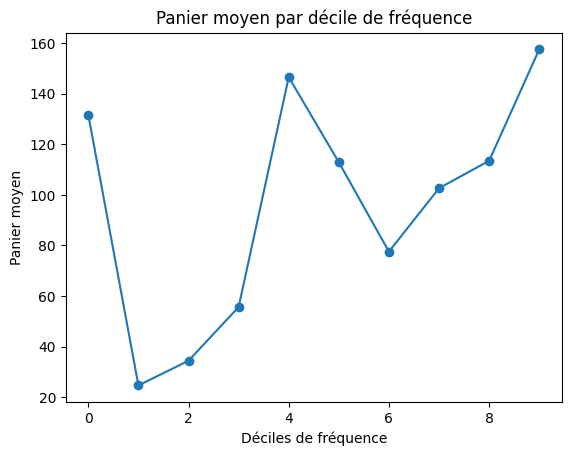

In [130]:
rfm["freq_bin"] = pd.qcut(rfm["frequency"].rank(method="first"), 10)
mean_basket = rfm.groupby("freq_bin")["avg_basket"].mean()

plt.figure()
plt.plot(range(len(mean_basket)), mean_basket.values, marker="o")
plt.title("Panier moyen par décile de fréquence")
plt.xlabel("Déciles de fréquence")
plt.ylabel("Panier moyen")
plt.show()

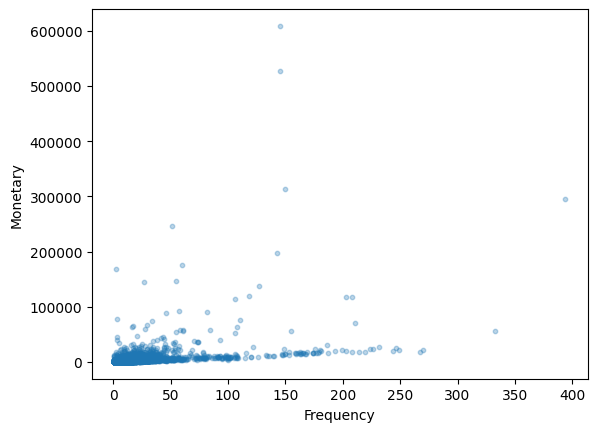

In [133]:
plt.figure()
plt.scatter(rfm["frequency"], rfm["monetary"], alpha=0.3, s=10)
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.show()

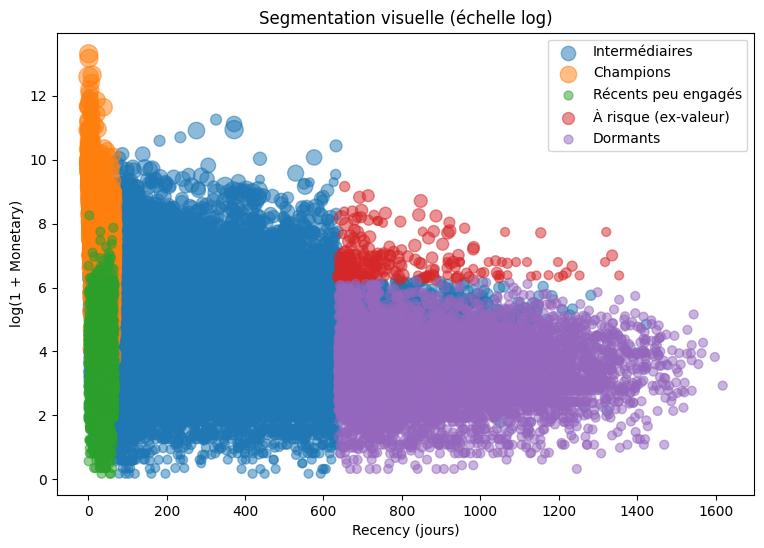

In [152]:
plt.figure(figsize=(9,6))

for s in rfm_plot["segment"].unique():
    sub = rfm_plot[rfm_plot["segment"] == s]
    plt.scatter(
        sub["recency"],
        np.log1p(sub["monetary"]),
        s=20 + 30*np.log1p(sub["frequency"]),
        alpha=0.5,
        label=s
    )

plt.xlabel("Recency (jours)")
plt.ylabel("log(1 + Monetary)")
plt.title("Segmentation visuelle (échelle log)")
plt.legend()
plt.show()

La visualisation récence × valeur montre une structuration naturelle du comportement client. On distingue clairement un groupe de clients récents à forte valeur (Champions), un segment de clients dormants à faible valeur, ainsi qu’un groupe intermédiaire. Toutefois, les frontières restent floues, justifiant une segmentation formelle par clustering.

In [159]:
df_clean.to_csv("transactions_clean.csv", index=False)

Analyse

TP2

In [153]:
#Préparation + Snapshot Date
import pandas as pd
import numpy as np

df = df_clean.copy()
df["invoice_date"] = pd.to_datetime(df["invoice_date"], errors="coerce")
df = df.dropna(subset=["customer_id", "invoice_id", "invoice_date"])

# Snapshot date = lendemain du dernier jour observé
snapshot_date = df["invoice_date"].max() + pd.Timedelta(days=1)

print("Snapshot date:", snapshot_date)

Snapshot date: 2011-12-10 12:50:00


In [154]:
rfm = df.groupby("customer_id").agg(
    last_purchase=("invoice_date", "max"),
    first_purchase=("invoice_date", "min"),
    frequency=("invoice_id", "nunique"),
    monetary=("line_total", "sum")
)

# Recency = nb jours depuis dernier achat
rfm["recency"] = (snapshot_date - rfm["last_purchase"]).dt.days

# Tenure (ancienneté) = nb jours depuis premier achat
rfm["tenure_days"] = (snapshot_date - rfm["first_purchase"]).dt.days

rfm.drop(columns=["last_purchase", "first_purchase"], inplace=True)

rfm.head()

,frequency,monetary,recency,tenure_days
customer_id,,,,
12346.0,3,77352.96,326,647
12347.0,8,5633.32,2,404
12348.0,5,1658.40,75,438
12349.0,3,3678.69,19,589
12350.0,1,294.40,310,310


In [157]:
rfm["avg_basket"] = rfm["monetary"] / rfm["frequency"]

In [160]:
import pandas as pd
import numpy as np

# Charger le dataset nettoyé
df_clean = pd.read_csv(r"C:\Users\reube\Data_marketing\transactions_clean.csv")

# Dates
df_clean["invoice_date"] = pd.to_datetime(df_clean["invoice_date"], errors="coerce")

df_clean.head()

C:\Users\reube\AppData\Local\Temp\ipykernel_74784\2169184296.py:5: DtypeWarning: Columns (0: invoice_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clean = pd.read_csv(r"C:\Users\reube\Data_marketing\transactions_clean.csv")


,invoice_id,customer_id,product_code,product_name,quantity,unit_price,invoice_date,country,line_total
0,513574,NaN,22382,LUNCH BAG SPACEBOY DESIGN,2.0,4.21,2010-06-25 15:13:00,United Kingdom,8.42
1,609421,NaN,21028,PURPLE GEMSTONE BRACELET,2.0,8.95,2011-10-16 12:20:00,United Kingdom,17.90
2,515609,NaN,47591B,SCOTTIES CHILDRENS APRON,1.0,1.66,2010-07-13 15:44:00,United Kingdom,1.66
3,501320,15123.0,22334,DINOSAUR PARTY BAG + STICKER SET,8.0,1.65,2010-03-16 09:49:00,United Kingdom,13.20
4,521822,12714.0,21933,PINK VINTAGE PAISLEY PICNIC BAG,5.0,2.95,2010-09-09 10:37:00,France,14.75


In [161]:
print("Lignes :", len(df_clean))
print("Clients uniques :", df_clean["customer_id"].nunique())
print("Invoices uniques :", df_clean["invoice_id"].nunique())

df_clean.isna().sum().sort_values(ascending=False).head(10)

Lignes : 1787439
Clients uniques : 48849
Invoices uniques : 301898


customer_id     406175
product_name      3089
invoice_id           0
product_code         0
quantity             0
unit_price           0
invoice_date         0
country              0
line_total           0
dtype: int64

In [162]:
#Préparation + Snapshot Date
import pandas as pd
import numpy as np

df = df_clean.copy()
df["invoice_date"] = pd.to_datetime(df["invoice_date"], errors="coerce")
df = df.dropna(subset=["customer_id", "invoice_id", "invoice_date"])

# Snapshot date = lendemain du dernier jour observé
snapshot_date = df["invoice_date"].max() + pd.Timedelta(days=1)

print("Snapshot date:", snapshot_date)

Snapshot date: 2011-12-10 12:50:00


In [170]:
#nombre de jours entre son dernier achat et la date de référence (date max du dataset)
df["recency"] = (snapshot_date - df["invoice_date"]).dt.days
print(df[["invoice_date", "recency"]].head())

         invoice_date  recency
3 2010-03-16 09:49:00      634
4 2010-09-09 10:37:00      457
6 2011-01-02 12:20:00      342
7 2011-05-26 13:01:00      197
9 2009-12-08 12:33:00      732


In [167]:
#nombre de factures distinctes sur la période complète
num_invoices = df_clean["invoice_id"].nunique()
print("Nombre de factures distinctes :", num_invoices)


Nombre de factures distinctes : 301898
